=== Dataset Overview ===
           TV      Radio   Newspaper      Sales
0  111.301697  31.844770   12.025184  13.488462
1  281.445935   4.173342  102.920265  15.941149
2  216.857811   8.016784   57.747195  14.333332
3  177.483850  44.568288   94.268214  18.502121
4   46.772305  30.078881   36.689640  10.189396

Shape: (200, 4)

Basic Statistics:
           TV   Radio  Newspaper   Sales
count  200.00  200.00     200.00  200.00
mean   143.63   25.02      59.50   14.21
std     87.08   14.53      34.94    4.83
min      2.33    0.25       1.53    2.42
25%     68.20   12.97      29.35   10.29
50%    146.72   26.87      60.04   14.36
75%    224.20   36.81      92.52   18.01
max    292.13   49.13     113.97   23.15


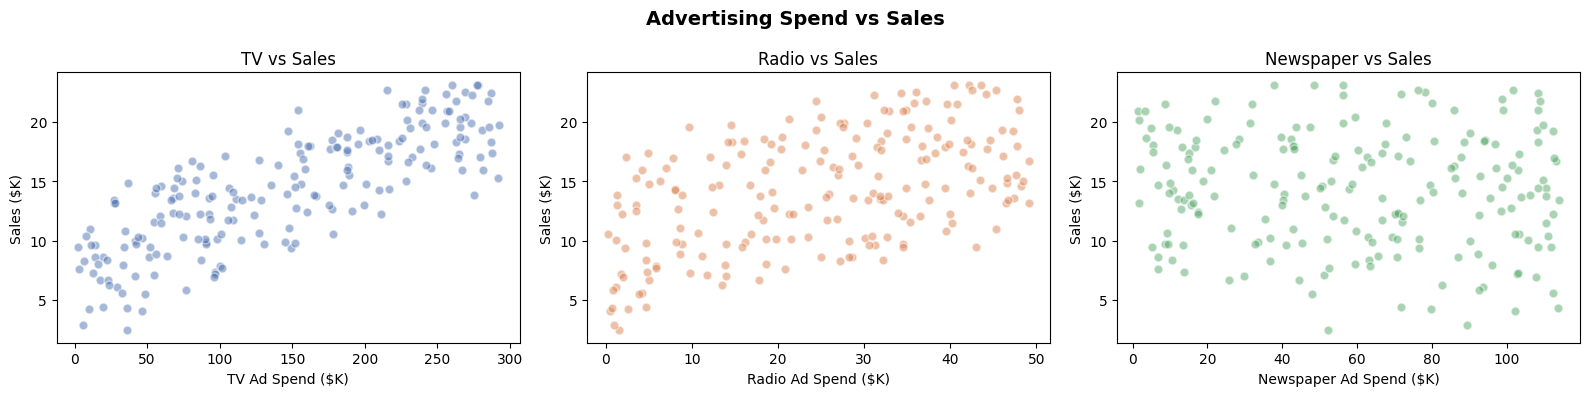

[Saved] sales_scatter.png


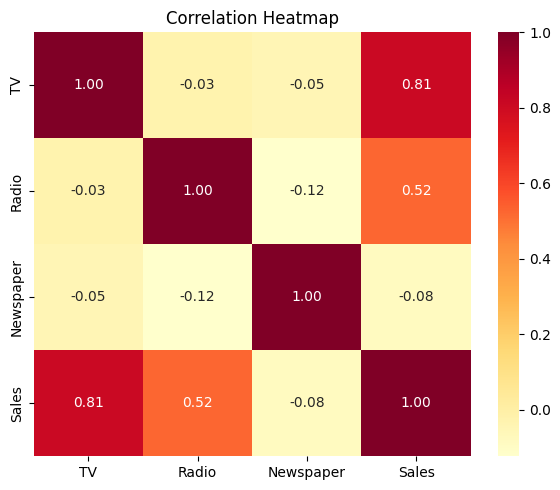

[Saved] sales_correlation.png

=== Model Comparison ===

Linear Regression:
  MAE  : 0.7049
  RMSE : 0.8309
  R²   : 0.9699

Random Forest:
  MAE  : 0.9087
  RMSE : 1.1744
  R²   : 0.9399


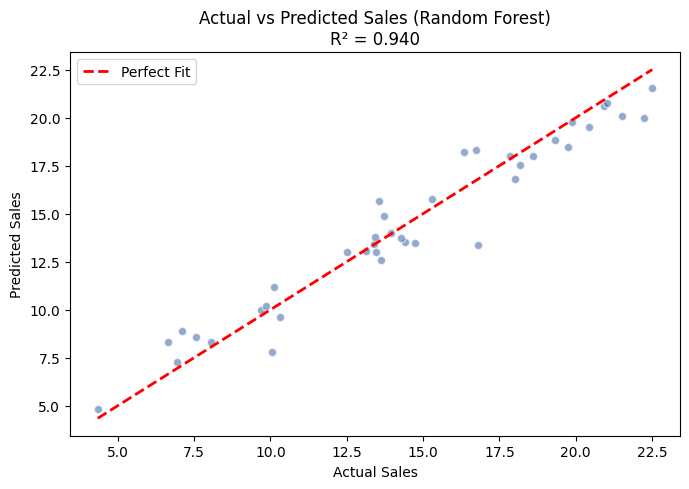

[Saved] sales_actual_vs_predicted.png


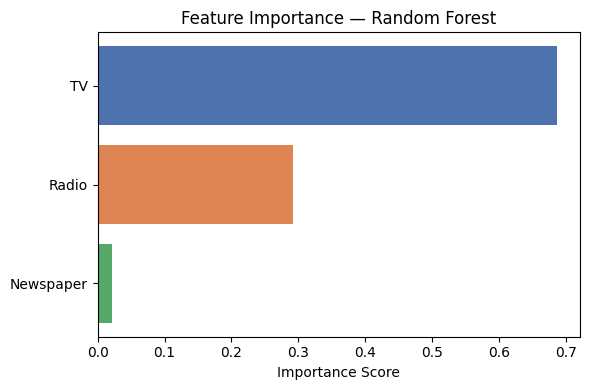

[Saved] sales_feature_importance.png

        💰 SALES PREDICTION TOOL 💰
Enter your advertising budget and the model
will predict your expected sales!

Enter your advertising spend (in $000s):
  TV Ad Spend        (e.g. 150): 150
  Radio Ad Spend     (e.g.  30): 30
  Newspaper Ad Spend (e.g.  10): 10

──────────────────────────────────────
  📊 PREDICTION RESULTS
──────────────────────────────────────
  TV Spend        : $150.0K
  Radio Spend     : $30.0K
  Newspaper Spend : $10.0K
  Total Budget    : $190.0K
  ─────────────────────────────────
  Predicted Sales (Random Forest) : $14.75K
  Predicted Sales (Linear Model)  : $15.20K
  Estimated ROI                   : -92.2%

  Budget Allocation:
    TV          150.0K  ███████████████████████
    Radio        30.0K  ████
    Newspaper    10.0K  █
──────────────────────────────────────

Predict for another budget? (yes/no): no

Thank you for using the Sales Predictor! 💰


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
n = 200
TV        = np.random.uniform(0.7, 296, n)
Radio     = np.random.uniform(0.0, 49.6, n)
Newspaper = np.random.uniform(0.3, 114, n)
Sales     = 2.9 + 0.046*TV + 0.188*Radio + 0.001*Newspaper + np.random.normal(0, 1, n)

df = pd.DataFrame({'TV': TV, 'Radio': Radio, 'Newspaper': Newspaper, 'Sales': Sales})

print("=== Dataset Overview ===")
print(df.head())
print(f"\nShape: {df.shape}")
print("\nBasic Statistics:")
print(df.describe().round(2))


fig, axes = plt.subplots(1, 3, figsize=(16, 4))
channels = ['TV', 'Radio', 'Newspaper']
colors   = ['#4C72B0', '#DD8452', '#55A868']

for ax, col, color in zip(axes, channels, colors):
    ax.scatter(df[col], df['Sales'], alpha=0.5, color=color, edgecolors='white', s=40)
    ax.set_xlabel(f'{col} Ad Spend ($K)')
    ax.set_ylabel('Sales ($K)')
    ax.set_title(f'{col} vs Sales')

plt.suptitle('Advertising Spend vs Sales', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sales_scatter.png', dpi=150)
plt.show()
print("[Saved] sales_scatter.png")


plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap='YlOrRd', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('sales_correlation.png', dpi=150)
plt.show()
print("[Saved] sales_correlation.png")


X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)


models = {
    'Linear Regression':  LinearRegression(),
    'Random Forest':      RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, m in models.items():
    m.fit(X_train_s, y_train)
    preds = m.predict(X_test_s)
    results[name] = {
        'MAE':  mean_absolute_error(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'R²':   r2_score(y_test, preds),
        'preds': preds
    }


print("\n=== Model Comparison ===")
for name, res in results.items():
    print(f"\n{name}:")
    print(f"  MAE  : {res['MAE']:.4f}")
    print(f"  RMSE : {res['RMSE']:.4f}")
    print(f"  R²   : {res['R²']:.4f}")

best_preds = results['Random Forest']['preds']
plt.figure(figsize=(7, 5))
plt.scatter(y_test, best_preds, alpha=0.6, color='#4C72B0', edgecolors='white')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Fit')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title(f"Actual vs Predicted Sales (Random Forest)\nR² = {results['Random Forest']['R²']:.3f}")
plt.legend()
plt.tight_layout()
plt.savefig('sales_actual_vs_predicted.png', dpi=150)
plt.show()
print("[Saved] sales_actual_vs_predicted.png")


rf_model = models['Random Forest']
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({'Feature': channels, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(6, 4))
plt.barh(feat_df['Feature'], feat_df['Importance'],
         color=['#55A868', '#DD8452', '#4C72B0'])
plt.xlabel('Importance Score')
plt.title('Feature Importance — Random Forest')
plt.tight_layout()
plt.savefig('sales_feature_importance.png', dpi=150)
plt.show()
print("[Saved] sales_feature_importance.png")


print("\n" + "="*52)
print("        💰 SALES PREDICTION TOOL 💰")
print("="*52)
print("Enter your advertising budget and the model")
print("will predict your expected sales!\n")

while True:
    try:
        print("Enter your advertising spend (in $000s):")
        tv        = float(input("  TV Ad Spend        (e.g. 150): "))
        radio     = float(input("  Radio Ad Spend     (e.g.  30): "))
        newspaper = float(input("  Newspaper Ad Spend (e.g.  10): "))

        new_budget   = pd.DataFrame({'TV': [tv], 'Radio': [radio], 'Newspaper': [newspaper]})
        new_budget_s = scaler.transform(new_budget)

        pred_rf  = rf_model.predict(new_budget_s)[0]
        pred_lr  = models['Linear Regression'].predict(new_budget_s)[0]
        total    = tv + radio + newspaper
        roi      = ((pred_rf - total) / total) * 100 if total > 0 else 0

        print("\n──────────────────────────────────────")
        print("  📊 PREDICTION RESULTS")
        print("──────────────────────────────────────")
        print(f"  TV Spend        : ${tv:.1f}K")
        print(f"  Radio Spend     : ${radio:.1f}K")
        print(f"  Newspaper Spend : ${newspaper:.1f}K")
        print(f"  Total Budget    : ${total:.1f}K")
        print("  ─────────────────────────────────")
        print(f"  Predicted Sales (Random Forest) : ${pred_rf:.2f}K")
        print(f"  Predicted Sales (Linear Model)  : ${pred_lr:.2f}K")
        print(f"  Estimated ROI                   : {roi:.1f}%")


        print("\n  Budget Allocation:")
        for label, val in [("TV       ", tv), ("Radio    ", radio), ("Newspaper", newspaper)]:
            bar = "█" * int((val / (total + 1e-9)) * 30)
            print(f"    {label}  {val:6.1f}K  {bar}")
        print("──────────────────────────────────────")

    except ValueError:
        print("⚠️  Invalid input! Please enter numeric values only.\n")

    again = input("\nPredict for another budget? (yes/no): ").strip().lower()
    if again not in ('yes', 'y'):
        print("\nThank you for using the Sales Predictor! 💰")
        break
    print()
